# Spaceship Titanic

Predict which passengers were transported to an alternate dimension.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 1. Load Data

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

train.shape, test.shape

((8693, 14), (4277, 13))

In [3]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


## 2. EDA

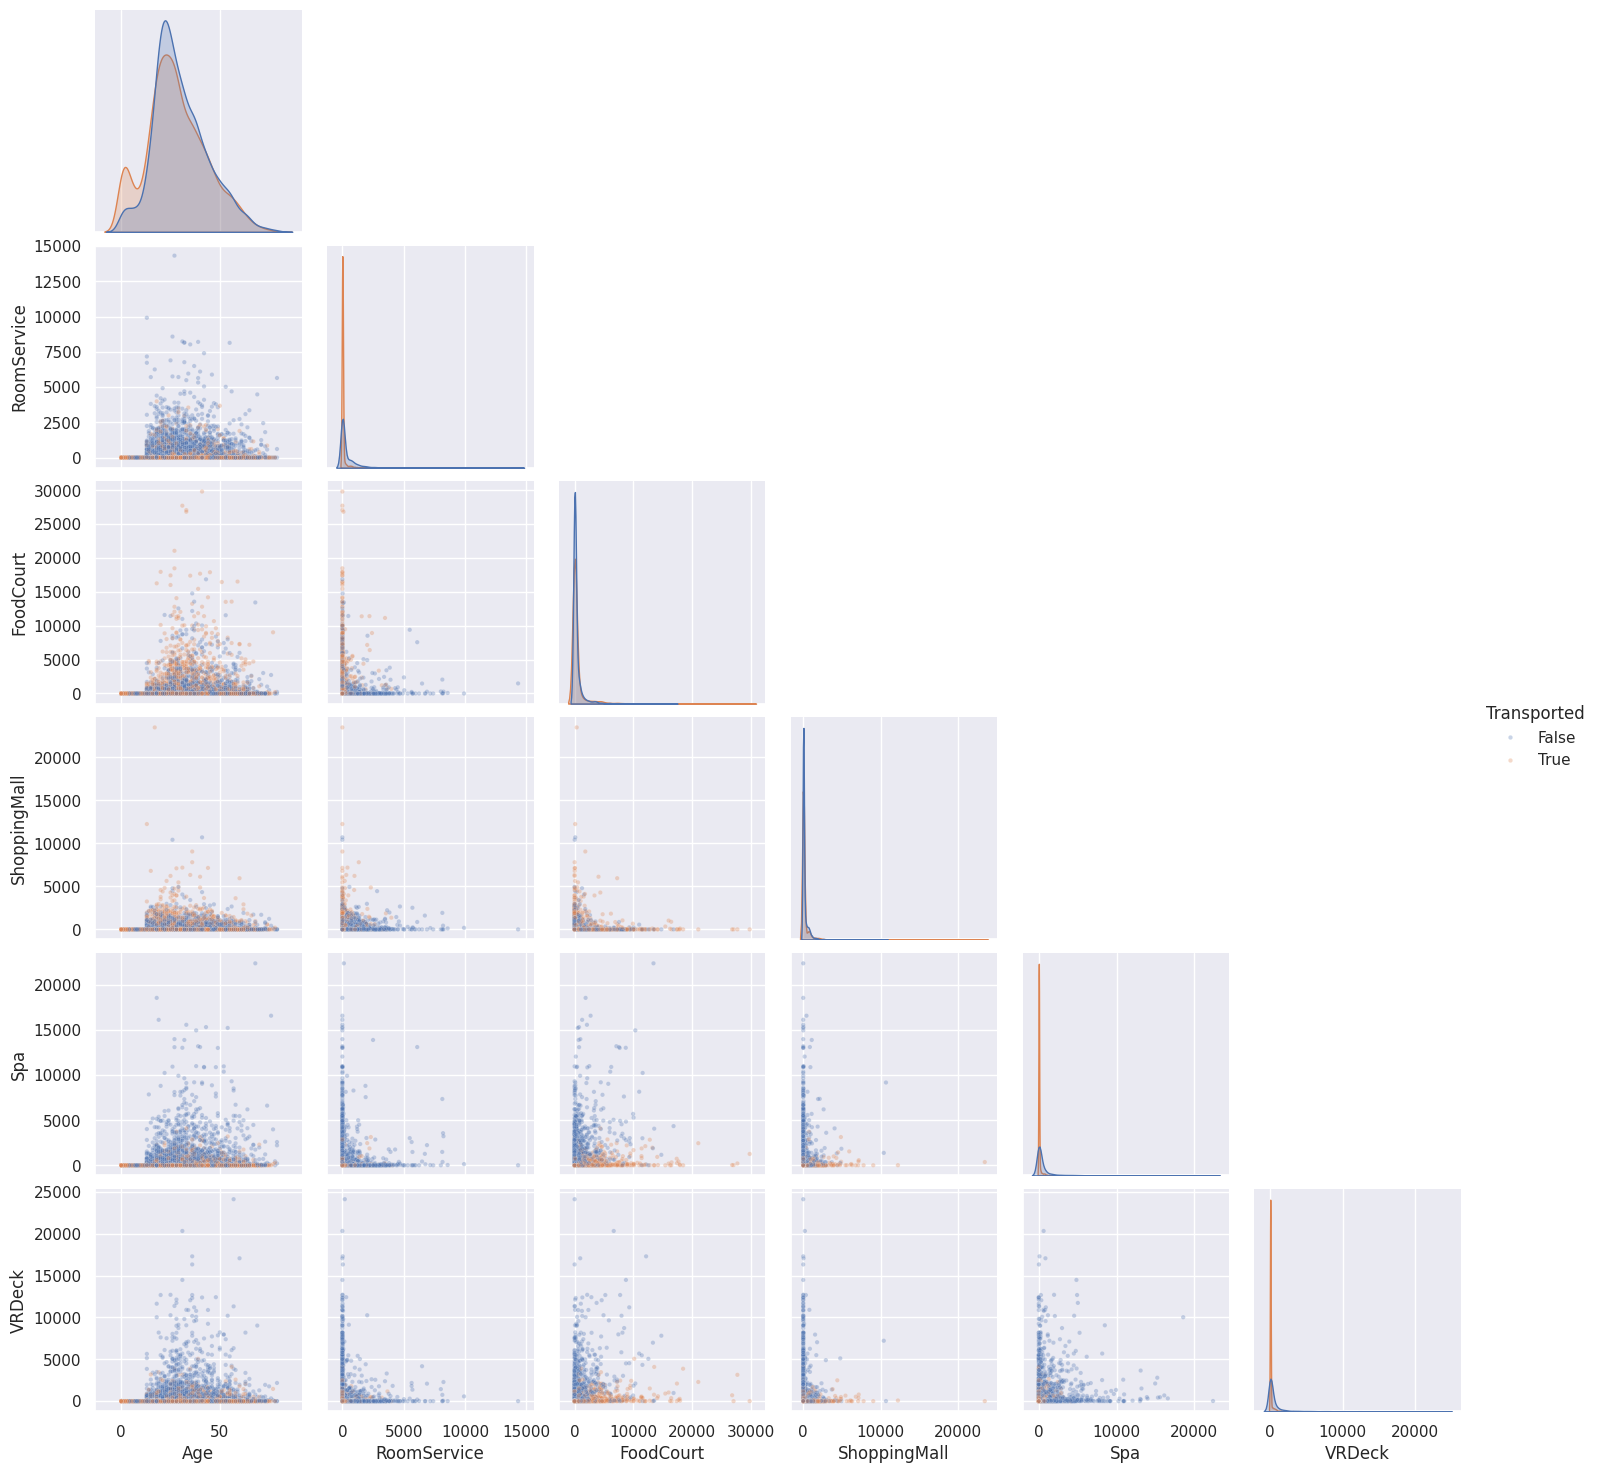

In [5]:
numerical_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
sns.pairplot(train, vars=numerical_cols, hue="Transported", diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10}, corner=True, height=2.5)
plt.show()

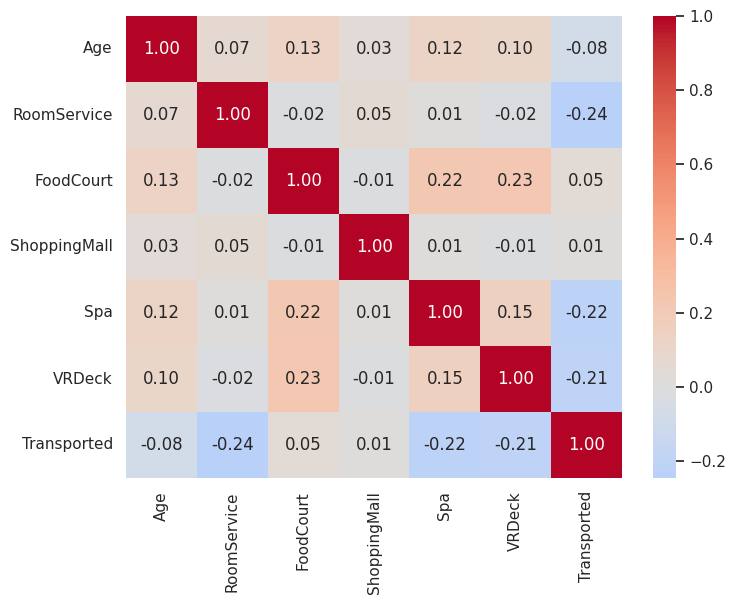

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(train[numerical_cols + ["Transported"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

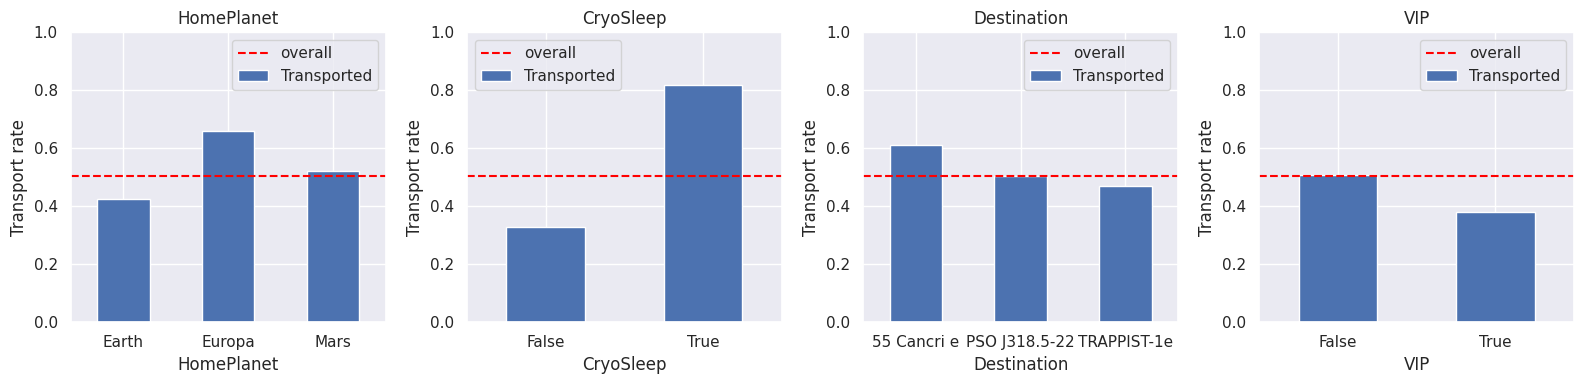

In [7]:
categorical_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 4))
for ax, col in zip(axes, categorical_cols):
    train.groupby(col)["Transported"].mean().plot.bar(ax=ax, rot=0)
    ax.set_ylabel("Transport rate")
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.axhline(train["Transported"].mean(), color="red", linestyle="--", label="overall")
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
for col in categorical_cols:
    print(f"--- {col} ---")
    print(train[col].value_counts(dropna=False))
    print()

--- HomePlanet ---
HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64

--- CryoSleep ---
CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64

--- Destination ---
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64

--- VIP ---
VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64



In [9]:
train["Cabin"].head(10)

0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
5    F/0/P
6    F/2/S
7    G/0/S
8    F/3/S
9    B/1/P
Name: Cabin, dtype: str

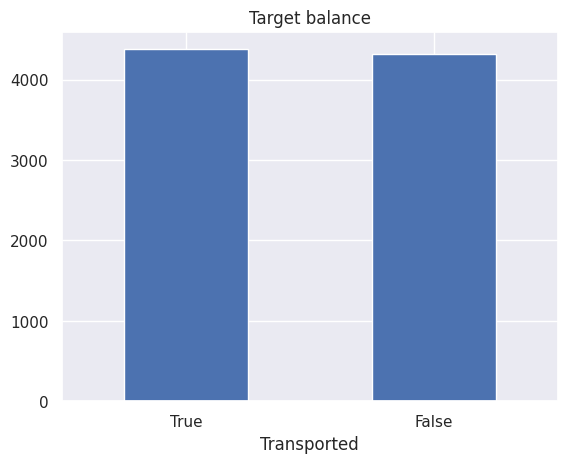

In [10]:
train["Transported"].value_counts().plot.bar(rot=0)
plt.title("Target balance")
plt.show()

In [11]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"{'Column':<15} {'Missing':>7} {'%':>6}")
print("-" * 30)
for col, count in missing.items():
    print(f"{col:<15} {count:>7} {count / len(train) * 100:>5.1f}%")

Column          Missing      %
------------------------------
CryoSleep           217   2.5%
ShoppingMall        208   2.4%
VIP                 203   2.3%
HomePlanet          201   2.3%
Name                200   2.3%
Cabin               199   2.3%
VRDeck              188   2.2%
FoodCourt           183   2.1%
Spa                 183   2.1%
Destination         182   2.1%
RoomService         181   2.1%
Age                 179   2.1%


In [12]:
train.isnull().sum(axis=1).value_counts().sort_index()

0    6606
1    1867
2     203
3      17
Name: count, dtype: int64

## 3. Preprocessing & Feature Engineering

In [13]:
bool_cols = ["Transported", "CryoSleep", "VIP"]
for col in bool_cols:
    train[col] = train[col].map({True: 1, False: 0, "True": 1, "False": 0})

train[bool_cols].head()

,Transported,CryoSleep,VIP
0,0,0.0,0.0
1,1,0.0,0.0
2,0,0.0,1.0
3,0,0.0,0.0
4,1,0.0,0.0


In [14]:
train["PassengerId"] = train["PassengerId"].str.split("_").str[0].astype(int)

train["PassengerId"].head()

0    1
1    2
2    3
3    3
4    4
Name: PassengerId, dtype: int64

In [15]:
train = pd.get_dummies(train, columns=["HomePlanet", "Destination"], dtype=int)

train.head()

,PassengerId,CryoSleep,Cabin,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,1,0.0,B/0/P,39.0,0.0,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0,0,1,0,0,0,1
1,2,0.0,F/0/S,24.0,0.0,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1,1,0,0,0,0,1
2,3,0.0,A/0/S,58.0,1.0,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0,0,1,0,0,0,1
3,3,0.0,A/0/S,33.0,0.0,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0,0,1,0,0,0,1
4,4,0.0,F/1/S,16.0,0.0,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1,1,0,0,0,0,1


In [16]:
cabin_split = train["Cabin"].str.split("/", expand=True)
train["CabinDeck"] = cabin_split[0]
train["CabinNum"] = cabin_split[1].astype(float)
train["CabinSide"] = cabin_split[2].map({"P": 0, "S": 1})
train.drop(columns=["Cabin"], inplace=True)

train = pd.get_dummies(train, columns=["CabinDeck"], dtype=int)

train[["CabinNum", "CabinSide"] + [c for c in train.columns if c.startswith("CabinDeck_")]].head()

,CabinNum,CabinSide,CabinDeck_A,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T
0,0.0,0.0,0,1,0,0,0,0,0,0
1,0.0,1.0,0,0,0,0,0,1,0,0
2,0.0,1.0,1,0,0,0,0,0,0,0
3,0.0,1.0,1,0,0,0,0,0,0,0
4,1.0,1.0,0,0,0,0,0,1,0,0


In [17]:
train["LastName"] = train["Name"].str.split().str[-1]
train.drop(columns=["Name"], inplace=True)

train["LastName"].head()

0      Ofracculy
1          Vines
2         Susent
3         Susent
4    Santantines
Name: LastName, dtype: object

In [18]:
train["FamilySize"] = train.groupby("LastName")["LastName"].transform("count")
train.drop(columns=["LastName"], inplace=True)

train["FamilySize"].value_counts().sort_index()

FamilySize
1.0      382
2.0      800
3.0     1164
4.0     1280
5.0     1280
6.0     1038
7.0      833
8.0      544
9.0      315
10.0     300
11.0     275
12.0      84
13.0      78
14.0      56
15.0      30
16.0      16
18.0      18
Name: count, dtype: int64

In [19]:
from sklearn.impute import KNNImputer

spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# CryoSleep passengers spent 0
for col in spending_cols:
    train.loc[train["CryoSleep"] == 1, col] = train.loc[train["CryoSleep"] == 1, col].fillna(0)

# KNN imputation for remaining NaNs (fit on features only, not target)
feature_cols = [c for c in train.columns if c != "Transported"]
imputer = KNNImputer(n_neighbors=5)
train[feature_cols] = imputer.fit_transform(train[feature_cols])

print("Remaining NaNs:", train.isnull().sum().sum())

Remaining NaNs: 0


In [20]:
spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train["TotalSpending"] = train[spending_cols].sum(axis=1)
train["NoSpending"] = (train["TotalSpending"] == 0).astype(int)
train["AgeGroup"] = pd.cut(train["Age"], bins=[0, 12, 18, 40, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
for col in spending_cols:
    train[f"{col}_ratio"] = train[col] / train["TotalSpending"].replace(0, 1)

# Log transform spending features
for col in spending_cols + ["TotalSpending"]:
    train[f"Log_{col}"] = np.log1p(train[col])

train[["TotalSpending", "Log_TotalSpending", "NoSpending"]].head()

,TotalSpending,Log_TotalSpending,NoSpending
0,0.0,0.000000,1
1,736.0,6.602588,0
2,10383.0,9.248021,0
3,5176.0,8.551981,0
4,1091.0,6.995766,0


## 4. Baseline Model

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

X = train.drop(columns=["Transported"])
y = train["Transported"]

rf = RandomForestClassifier(random_state=42)
scores = cross_val_score(rf, X, y, cv=10, scoring="accuracy")

print(f"Fold scores: {scores}")
print(f"Mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Fold scores: [0.7862069  0.73793103 0.73333333 0.73647871 0.79056387 0.81242808
 0.82163406 0.80207135 0.81357883 0.76064442]
Mean accuracy: 0.7795 (+/- 0.0328)


## 5. Improved Model

In [22]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, verbosity=0),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10, scoring="accuracy")
    print(f"{name:15s}  {scores.mean():.4f} (+/- {scores.std():.4f})")

RandomForest     0.7795 (+/- 0.0328)
XGBoost          0.7225 (+/- 0.0739)
LightGBM         0.7484 (+/- 0.0708)


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def xgb_objective(trial):
    clf = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 2000),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        learning_rate=trial.suggest_float("lr", 0.005, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample", 0.3, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        random_state=42, verbosity=0, n_jobs=-1, device="cuda",
    )
    return cross_val_score(clf, X, y, cv=5, scoring="accuracy").mean()

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=200, show_progress_bar=True)

print(f"\nBest XGBoost accuracy: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

In [27]:
from sklearn.ensemble import VotingClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

best_xgb = XGBClassifier(
    n_estimators=139, max_depth=9, learning_rate=0.0108,
    subsample=0.511, colsample_bytree=0.451, min_child_weight=20,
    gamma=2.085, reg_alpha=6.311, reg_lambda=6.231,
    random_state=42, verbosity=0, n_jobs=-1,
)
best_lgb = LGBMClassifier(
    n_estimators=133, max_depth=9, learning_rate=0.0102,
    subsample=0.797, colsample_bytree=0.734, min_child_weight=1.65,
    num_leaves=14, reg_alpha=1.13e-6, reg_lambda=3.71e-7,
    random_state=42, verbose=-1, n_jobs=-1,
)
best_et = ExtraTreesClassifier(
    n_estimators=260, max_depth=13, min_samples_split=16, min_samples_leaf=8,
    random_state=42, n_jobs=-1,
)

stacker = StackingClassifier(
    estimators=[("xgb", best_xgb), ("lgb", best_lgb), ("et", best_et)],
    final_estimator=LogisticRegression(),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

scores = cross_val_score(stacker, X, y, cv=10, scoring="accuracy")
print(f"Stacking (XGB+LGBM+ET): {scores.mean():.4f} (+/- {scores.std():.4f})")

Stacking (XGB+LGBM+ET): 0.8031 (+/- 0.0142)


In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
thresholds = np.arange(0.45, 0.56, 0.01)
threshold_scores = {t: [] for t in thresholds}
scores_default = []

for train_idx, val_idx in kf.split(X, y):
    stacker.fit(X.iloc[train_idx], y.iloc[train_idx])
    proba = stacker.predict_proba(X.iloc[val_idx])[:, 1]
    y_val = y.iloc[val_idx]

    scores_default.append(accuracy_score(y_val, proba >= 0.5))
    for t in thresholds:
        threshold_scores[t].append(accuracy_score(y_val, proba >= t))

print(f"{'Threshold':>10s}  {'Accuracy':>8s}")
print("-" * 22)
for t in thresholds:
    mean = np.mean(threshold_scores[t])
    marker = " <-- best" if mean == max(np.mean(v) for v in threshold_scores.values()) else ""
    print(f"{t:>10.2f}  {mean:.4f}{marker}")

best_threshold = max(thresholds, key=lambda t: np.mean(threshold_scores[t]))
print(f"\nDefault (0.50): {np.mean(scores_default):.4f}")
print(f"Best threshold: {best_threshold:.2f} -> {np.mean(threshold_scores[best_threshold]):.4f}")

 Threshold  Accuracy
----------------------
      0.45  0.8036
      0.46  0.8033
      0.47  0.8040
      0.48  0.8040
      0.49  0.8046
      0.50  0.8046
      0.51  0.8050
      0.52  0.8036
      0.53  0.8048
      0.54  0.8042
      0.55  0.8046
      0.56  0.8055 <-- best

Default (0.50): 0.8046
Best threshold: 0.56 -> 0.8055


## 6. Submission

In [29]:
THRESHOLD = 0.50  # Change to best_threshold if needed

test_raw = pd.read_csv("data/test.csv")
test_ids = test_raw["PassengerId"].copy()

# Same preprocessing as train
test = test_raw.copy()
for col in ["CryoSleep", "VIP"]:
    test[col] = test[col].map({True: 1, False: 0, "True": 1, "False": 0})
test["PassengerId"] = test["PassengerId"].str.split("_").str[0].astype(int)
test = pd.get_dummies(test, columns=["HomePlanet", "Destination"], dtype=int)

cabin_split = test["Cabin"].str.split("/", expand=True)
test["CabinDeck"] = cabin_split[0]
test["CabinNum"] = cabin_split[1].astype(float)
test["CabinSide"] = cabin_split[2].map({"P": 0, "S": 1})
test.drop(columns=["Cabin"], inplace=True)
test = pd.get_dummies(test, columns=["CabinDeck"], dtype=int)

test["LastName"] = test["Name"].str.split().str[-1]
test.drop(columns=["Name"], inplace=True)
test["FamilySize"] = test.groupby("LastName")["LastName"].transform("count")
test.drop(columns=["LastName"], inplace=True)

# CryoSleep passengers spent 0
for col in spending_cols:
    test.loc[test["CryoSleep"] == 1, col] = test.loc[test["CryoSleep"] == 1, col].fillna(0)

# KNN imputation (use imputer fitted on train feature_cols)
# Align test columns to match imputer before transform
for col in feature_cols:
    if col not in test.columns:
        test[col] = 0
test[feature_cols] = imputer.transform(test[feature_cols])

# Engineered features
test["TotalSpending"] = test[spending_cols].sum(axis=1)
test["NoSpending"] = (test["TotalSpending"] == 0).astype(int)
test["AgeGroup"] = pd.cut(test["Age"], bins=[0, 12, 18, 40, 60, 100], labels=[0, 1, 2, 3, 4]).astype(float)
for col in spending_cols:
    test[f"{col}_ratio"] = test[col] / test["TotalSpending"].replace(0, 1)

# Log transform spending features
for col in spending_cols + ["TotalSpending"]:
    test[f"Log_{col}"] = np.log1p(test[col])

# Align columns with train
for col in X.columns:
    if col not in test.columns:
        test[col] = 0
test = test[X.columns]

# Train on full data and predict
stacker.fit(X, y)
proba = stacker.predict_proba(test)[:, 1]
preds = (proba >= THRESHOLD).astype(bool)

submission = pd.DataFrame({"PassengerId": test_ids, "Transported": preds})
submission.to_csv("data/submission.csv", index=False)
print(f"Threshold: {THRESHOLD}")
print(submission.head())
print(f"Submission shape: {submission.shape}")

Threshold: 0.5
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
Submission shape: (4277, 2)
